# Fidélité des volumes FreeSurfer après traitement

Dans `aseg.stats`, FreeSurfer donne un volume en mm³ pour chaque structure. Par exemple : hippocampe, ventricule ou putamen. Ce n'est pas le volume du fichier IRM entier.

La référence est toujours `brut/run-01` du même sujet. C'est le scan presque immobile, traité par FreeSurfer à partir de l'image brute.

On compare cette référence avec :

- `preproc/run-01`, `JDAC/run-01` et les variantes sur le scan presque immobile ;
- les mêmes conditions sur `run-02` et `run-03`, qui sont les scans bougés.

Ce notebook pose deux questions :

1. Les traitements changent-ils les volumes sur `run-01` ?
2. Sur les scans bougés, JDAC fait-il mieux que preproc ?

Le calcul est fait sujet par sujet. Chaque sujet donne une valeur par condition. C'est cette valeur qui est comparée entre conditions.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from IPython.display import Markdown
warnings.filterwarnings("ignore")

CONDITIONS = ["brut", "preproc", "jdac", "jdac_antiartonly", "jdac_nodenoise"]
LABELS = {
    "brut": "brut", "preproc": "preproc", "jdac": "JDAC",
    "jdac_antiartonly": "antiart ×1", "jdac_nodenoise": "antiart ×4",
}
ASEG_DIR = Path.home() / "Documents/derivatives/ds004332/aseg_stats"
ASEG_FILES = {
    "brut": "aseg_brut.csv",
    "preproc": "aseg_preproc.csv",
    "jdac": "aseg_jdac.csv",
    "jdac_antiartonly": "aseg_antiartonly.csv",
    "jdac_nodenoise": "aseg_nodenoise.csv",
}

# Lit une table aseg (format large : une ligne par acquisition, une colonne par
# structure) et la retourne en format long (une ligne par structure), avec les
# colonnes subject, run, measure, value_mm3, condition.
def load_table(condition, filename):
    wide = pd.read_csv(ASEG_DIR / filename, sep="	")
    id_col = "Measure:volume" if "Measure:volume" in wide.columns else wide.columns[0]
    # Sépare l'identifiant "sub-XX_run-YY" en sujet et run.
    ids = wide[id_col].astype(str).str.extract(r"(sub-[^_/\s]+)_(run-\d+)", expand=True)
    if ids.isna().any().any():
        raise ValueError(f"Identifiants non reconnus dans {filename}")
    return (wide.drop(columns=id_col)
            .assign(subject=ids[0].values, run=ids[1].values)
            .melt(id_vars=["subject", "run"], var_name="measure", value_name="value_mm3")
            .assign(condition=condition))

missing = [name for name in ASEG_FILES.values() if not (ASEG_DIR / name).is_file()]
if missing:
    raise FileNotFoundError("Tables absentes : " + ", ".join(missing))

# Empile les 5 conditions dans un seul tableau long d.
d = pd.concat([load_table(c, f) for c, f in ASEG_FILES.items()], ignore_index=True)
d["value_mm3"] = pd.to_numeric(d["value_mm3"], errors="coerce")
d["condition"] = pd.Categorical(d["condition"], CONDITIONS, ordered=True)

# Score de mouvement Agitation (covariable de la question 3), joint par sujet et run.
REPO = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "results/ds004332").exists()), Path.home() / "Documents/GitHub/jdac-motion-correction")
AGIT = REPO / "results/ds004332/agitation/ds004332_agitation_clinica.csv"
agit = pd.read_csv(AGIT).rename(columns={"sub":"subject", "condition":"run", "motion":"agitation"})
d = d.merge(agit[["subject", "run", "agitation"]], on=["subject", "run"], how="left")

# GLOBAL : six grands compartiments tissulaires, utilisés seulement par le
# tableau descriptif (sens de l'effet), jamais par le score principal.
GLOBAL = [
    "CortexVol", "TotalGrayVol", "CerebralWhiteMatterVol",
    "SubCortGrayVol", "CSF", "BrainSegVolNotVent",
]
GLOBAL_LABELS = {
    "CortexVol": "Substance grise corticale (CortexVol)",
    "TotalGrayVol": "Substance grise totale (TotalGrayVol)",
    "CerebralWhiteMatterVol": "Substance blanche cérébrale (CerebralWhiteMatterVol)",
    "SubCortGrayVol": "Substance grise sous-corticale (SubCortGrayVol)",
    "CSF": "LCR segmenté (CSF)",
    "BrainSegVolNotVent": "Cerveau segmenté hors ventricules (BrainSegVolNotVent)",
}
# EXCLUDED : mesures non anatomiques (ratios -to-eTIV, trous de surface,
# hypointensités). Base quasi nulle, un pourcentage n'y a pas de sens : écartées.
EXCLUDED = {
    "EstimatedTotalIntraCranialVol", "SegmentedTotalIntracranialVol",
    "BrainSegVol-to-eTIV", "MaskVol-to-eTIV",
    "SurfaceHoles", "lhSurfaceHoles", "rhSurfaceHoles",
    "WM-hypointensities", "Left-WM-hypointensities",
    "Right-WM-hypointensities", "non-WM-hypointensities",
    "Left-non-WM-hypointensities", "Right-non-WM-hypointensities",
}
base_median = (d[(d.condition=="brut") & (d.run=="run-01")]
               .groupby("measure", observed=True).value_mm3.median())
# Mesures assez grandes pour un pourcentage stable (> 100 mm³).
# On enlève les ratios et les mesures de qualité. Les six volumes du tableau
# descriptif sont calculés séparément.
score_measures = [m for m in base_median.index
                  if m not in EXCLUDED and m not in GLOBAL and base_median[m] > 100]

context = pd.DataFrame([{
    "Sujets": d.subject.nunique(),
    "Runs": d.run.nunique(),
    "Conditions": d.condition.nunique(),
    "Acquisitions disponibles": f"{d[['subject','run','condition']].drop_duplicates().shape[0]}/{d.subject.nunique()*d.run.nunique()*d.condition.nunique()}",
    "Mesures du score": len(score_measures),
}])
display(context)

,Sujets,Runs,Conditions,Acquisitions disponibles,Mesures du score
0,22,3,5,325/330,40


### Mesures utilisées

Le score principal utilise 40 mesures :

- 32 structures prises séparément, par exemple l'hippocampe gauche ou le putamen droit ;
- 8 grands volumes déjà calculés par FreeSurfer, par exemple `BrainSegVol`, les volumes de cortex et de substance blanche de chaque hémisphère, `SupraTentorialVol` et `MaskVol`.

Pour chaque mesure, on calcule l'écart en % par rapport à `brut/run-01`. Puis on prend la médiane des 40 écarts. Chaque mesure compte donc autant dans le score.

On enlève les structures de moins de 100 mm³, les ratios et les mesures de qualité. Leur pourcentage serait difficile à interpréter ici.

Le tableau suivant utilise seulement six grands volumes : grise corticale, grise totale, blanche cérébrale, grise sous-corticale, LCR et cerveau hors ventricules. Il sert juste à voir quel type de tissu augmente ou diminue. Il ne sert pas au test principal.

Les volumes de départ sont en **mm³**. Les tableaux montrent des **% par rapport à brut/run-01**.

### Méthode statistique

Les écarts sont résumés par la **médiane entre sujets**. L'incertitude vient d'un **IC95 bootstrap** (ré-échantillonnage des sujets), et chaque comparaison entre deux conditions est un **test apparié de Wilcoxon** (mêmes sujets), avec correction **Holm** pour les comparaisons multiples.

In [2]:
# IC95 de la médiane par bootstrap : on ré-échantillonne les sujets 10 000 fois
# et on regarde l'étendue de la médiane obtenue. Graine fixe -> reproductible.
def bootstrap_ci(values, n_boot=10000, seed=20260720):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    draws = rng.choice(values, size=(n_boot, len(values)), replace=True)
    return np.percentile(np.median(draws, axis=1), [2.5, 97.5])

# Compare deux conditions chez les MÊMES sujets (test apparié). Pour chaque paire :
# diff = candidat - comparateur, sa médiane, son IC95, un test de Wilcoxon.
# Holm corrige les p-values pour le nombre de comparaisons.
def paired_contrasts(scores, specs, value_col):
    wide = scores.pivot(index="subject", columns="condition", values=value_col)
    rows = []
    for label, candidate, comparator in specs:
        pair = wide[[candidate, comparator]].dropna()  # sujets présents dans les deux conditions
        diff = pair[candidate] - pair[comparator]
        lo, hi = bootstrap_ci(diff)
        p = stats.wilcoxon(diff).pvalue if len(diff) >= 3 and np.any(diff != 0) else 1.0
        rows.append({"comparaison":label, "n":len(diff),
                     "différence médiane (points %)":np.median(diff),
                     "IC95 bas":lo, "IC95 haut":hi, "p":p})
    out = pd.DataFrame(rows)
    out["p Holm"] = multipletests(out.p, method="holm")[1]
    return out

## 1. Le traitement modifie-t-il le scan presque immobile ?

Pour un sujet et une mesure donnée, la référence **R** = volume FreeSurfer du **brut/run-01**. Le volume comparé **T** est la sortie de la condition correspondante sur le **même run-01** : par exemple, `preproc/run-01`, `JDAC/run-01`, `antiart ×1/run-01` ou `antiart ×4/run-01`.

On calcule d'abord, structure par structure :

**erreur absolue (%) = |T − R| / R × 100**

Puis on prend la médiane des mesures du score pour ce sujet. Cette **erreur d'identité** répond seulement à « de combien le résultat s'éloigne-t-il du brut/run-01 ? » : elle est toujours positive ou nulle et ne dit donc pas si une structure grossit ou s'amincit. Une valeur faible est meilleure.

La comparaison principale est JDAC contre preproc, car JDAC est appliqué après ce preprocessing.

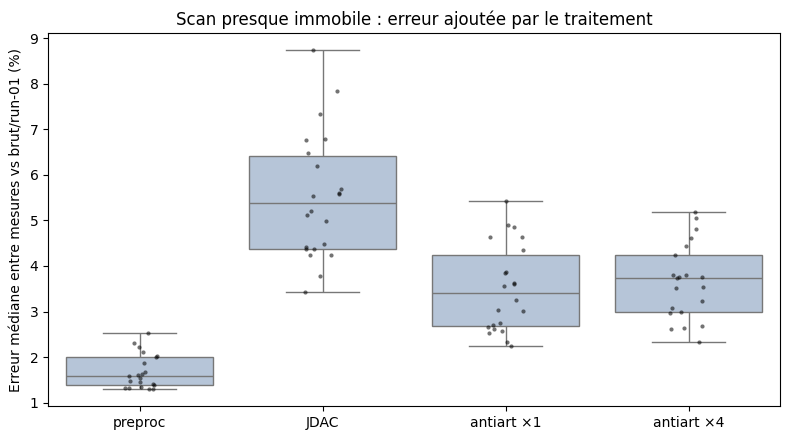

In [3]:
# Étape 1 : fixer, pour chaque sujet et chaque mesure, la référence R = brut/run-01.
ref = (d[(d.condition=="brut") & (d.run=="run-01") & d.measure.isin(score_measures)]
       [["subject","measure","value_mm3"]]
       .rename(columns={"value_mm3":"reference_mm3"}))

# Étape 2 : associer chaque sortie run-01 à R du même sujet.
still = (d[(d.run=="run-01") & d.measure.isin(score_measures)]
         .merge(ref, on=["subject","measure"], how="inner"))
# Étape 3 : prendre la valeur absolue. L'erreur est une distance à R.
still["error_pct"] = 100 * (still.value_mm3-still.reference_mm3).abs() / still.reference_mm3
# Étape 4 : prendre la médiane des mesures pour chaque sujet et condition.
identity = (still.groupby(["subject","condition"], observed=True).error_pct
            .median().reset_index(name="erreur_identite_pct"))

plt.figure(figsize=(8,4.5))
sns.boxplot(data=identity[identity.condition!="brut"], x="condition",
            y="erreur_identite_pct", order=CONDITIONS[1:], color="lightsteelblue")
sns.stripplot(data=identity[identity.condition!="brut"], x="condition",
              y="erreur_identite_pct", order=CONDITIONS[1:],
              color="black", alpha=.55, size=3)
plt.xticks(range(4), [LABELS[c] for c in CONDITIONS[1:]])
plt.ylabel("Erreur médiane entre mesures vs brut/run-01 (%)")
plt.xlabel("")
plt.title("Scan presque immobile : erreur ajoutée par le traitement")
plt.tight_layout()
plt.show()

# Repère de lecture : chaque point est un sujet ; une boîte plus haute = plus d'écart au brut/run-01.

Le tableau ci-dessous teste ces écarts par un contraste apparié `candidat − preproc` (mêmes sujets). L'interprétation est **sous** le tableau.

In [4]:
identity_tests = paired_contrasts(
    identity[identity.condition!="brut"],
    [
        ("JDAC − preproc", "jdac", "preproc"),
        ("antiart ×1 − preproc", "jdac_antiartonly", "preproc"),
        ("antiart ×4 − preproc", "jdac_nodenoise", "preproc"),
    ],
    "erreur_identite_pct",
)
display(identity_tests.round(3))

# Interprétation calculée à partir du tableau (aucune valeur écrite à la main).
jt = identity_tests.set_index("comparaison")
jdv, jdp = jt.loc["JDAC − preproc", ["différence médiane (points %)", "p Holm"]]
a1v = jt.loc["antiart ×1 − preproc", "différence médiane (points %)"]
a4v = jt.loc["antiart ×4 − preproc", "différence médiane (points %)"]
display(Markdown(
    "**Ce qu'on apprend.** Une différence *négative* voudrait dire « plus proche du brut que preproc » ; "
    "*positive*, « plus d'erreur que preproc ». "
    f"Les trois sont positives : sur le scan presque immobile, où il n'y a presque rien à corriger, "
    f"JDAC s'écarte du brut de **{jdv:+.1f} points %** de plus que preproc (p Holm {jdp:.2g}), "
    f"antiart ×1 de {a1v:+.1f}, antiart ×4 de {a4v:+.1f}. "
    "Aucun ne préserve donc l'anatomie immobile mieux que le simple preprocessing."))

,comparaison,n,différence médiane (points %),IC95 bas,IC95 haut,p,p Holm
0,JDAC − preproc,21,3.900,2.908,4.601,0.0,0.0
1,antiart ×1 − preproc,21,1.645,1.221,2.293,0.0,0.0
2,antiart ×4 − preproc,20,1.806,1.442,2.474,0.0,0.0


**Ce qu'on apprend.** Une différence *négative* voudrait dire « plus proche du brut que preproc » ; *positive*, « plus d'erreur que preproc ». Les trois sont positives : sur le scan presque immobile, où il n'y a presque rien à corriger, JDAC s'écarte du brut de **+3.9 points %** de plus que preproc (p Holm 2.9e-06), antiart ×1 de +1.6, antiart ×4 de +1.8. Aucun ne préserve donc l'anatomie immobile mieux que le simple preprocessing.

### Où se produit le changement ?

Tableau descriptif (il n'entre pas dans le test principal). Il montre le changement **signé** de six grands compartiments sur run-01, en **% par rapport à brut/run-01** (médiane sur les sujets). Signe gardé : négatif = compartiment plus petit qu'au brut, positif = plus grand.

| Nom FreeSurfer | En clair | Contenu |
|---|---|---|
| `CortexVol` | Substance grise corticale | somme des cortex gauche et droit |
| `TotalGrayVol` | Substance grise totale | grise corticale + sous-corticale + cervelet |
| `CerebralWhiteMatterVol` | Substance blanche cérébrale | blanche des deux hémisphères |
| `SubCortGrayVol` | Substance grise sous-corticale | noyaux gris profonds |
| `CSF` | LCR segmenté | voxels classés liquide cérébrospinal par aseg |
| `BrainSegVolNotVent` | Cerveau hors ventricules | cerveau segmenté, ventricules retirés |

L'interprétation des chiffres suit **sous** le tableau.

In [5]:
# Variation SIGNÉE (%) de chaque compartiment sur run-01 vs brut/run-01, médiane sur les sujets.
# Signe gardé : - = plus petit qu'au brut, + = plus grand.
gref = (d[(d.condition=="brut") & (d.run=="run-01") & d.measure.isin(GLOBAL)]
        [["subject","measure","value_mm3"]]
        .rename(columns={"value_mm3":"reference_mm3"}))
g = (d[(d.run=="run-01") & d.measure.isin(GLOBAL) & (d.condition!="brut")]
     .merge(gref, on=["subject","measure"], how="inner"))
g["signed_pct"] = 100 * (g.value_mm3-g.reference_mm3) / g.reference_mm3
# Table médiane : lignes = conditions, colonnes = compartiments (noms FreeSurfer d'origine).
gt = (g.groupby(["condition","measure"], observed=True).signed_pct
      .median().unstack("measure").reindex(CONDITIONS[1:])[GLOBAL])
disp = gt.copy()
disp.columns = [GLOBAL_LABELS[c] for c in disp.columns]
disp.index = [LABELS[c] for c in disp.index]
# Unité affichée dans chaque case : % signé.
display(disp.style.format("{:+.1f} %").set_caption("Variation vs brut/run-01 (% signé)"))

# Interprétation calculée (gt garde les noms d'origine).
j = gt.loc["jdac"]
prep_absmax = gt.loc["preproc"].abs().max()
display(Markdown(
    "**Ce qu'on apprend.** Le changement a un sens précis, ce n'est pas du bruit. "
    f"Sur run-01, JDAC réduit la substance grise corticale (**{j['CortexVol']:+.0f} %**) et augmente la "
    f"substance blanche (**{j['CerebralWhiteMatterVol']:+.0f} %**) et le LCR (**{j['CSF']:+.0f} %**) : "
    "de la matière classée « grise » sur le brut passe en « blanche » ou en « LCR » après JDAC. "
    "C'est la signature d'un lissage des frontières gris/blanc, pas d'une correction du mouvement. "
    f"En comparaison, preproc reste sous ±{prep_absmax:.0f} % sur tous les compartiments."))

,Substance grise corticale (CortexVol),Substance grise totale (TotalGrayVol),Substance blanche cérébrale (CerebralWhiteMatterVol),Substance grise sous-corticale (SubCortGrayVol),LCR segmenté (CSF),Cerveau segmenté hors ventricules (BrainSegVolNotVent)
preproc,-4.1 %,-2.4 %,-0.2 %,-0.6 %,+3.0 %,-1.0 %
JDAC,-14.3 %,-11.2 %,+10.7 %,-2.5 %,+9.9 %,-3.0 %
antiart ×1,-8.2 %,-5.9 %,+3.2 %,-2.4 %,+3.1 %,-1.8 %
antiart ×4,-1.2 %,-2.0 %,-1.5 %,-6.1 %,+5.1 %,-1.5 %


**Ce qu'on apprend.** Le changement a un sens précis, ce n'est pas du bruit. Sur run-01, JDAC réduit la substance grise corticale (**-14 %**) et augmente la substance blanche (**+11 %**) et le LCR (**+10 %**) : de la matière classée « grise » sur le brut passe en « blanche » ou en « LCR » après JDAC. C'est la signature d'un lissage des frontières gris/blanc, pas d'une correction du mouvement. En comparaison, preproc reste sous ±4 % sur tous les compartiments.

## 2. Sur les scans bougés, le traitement fait-il mieux que preproc ?

Même calcul que la question 1, mais **T** est le volume de la condition sur un run bougé (`run-02` nodding, `run-03` shaking). La référence **R** reste le **brut/run-01 du même sujet**.

Le boxplot ci-dessous montre le **niveau d'erreur absolue** par sujet et par condition (donc ≥ 0, jamais négatif). Une boîte plus basse = plus fidèle au brut/run-01. Le tableau qui suit teste ces écarts (`candidat − preproc`) ; chaque interprétation est **sous** sa sortie.

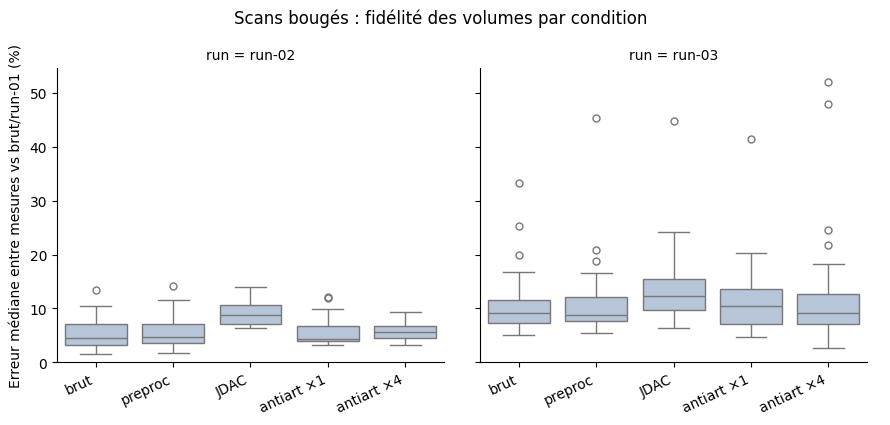

**Ce qu'on voit.** Boîte plus basse = volumes plus proches du brut/run-01. L'erreur médiane la plus faible revient à **antiart ×1** sur run-02 et **preproc** sur run-03, mais les écarts entre conditions sont faibles à l'œil. Le tableau ci-dessous teste s'ils sont réels.

In [6]:
# Étape 1 : associer les sorties des runs bougés à R = brut/run-01.
moved = (d[d.run.isin(["run-02","run-03"]) & d.measure.isin(score_measures)]
         .merge(ref, on=["subject","measure"], how="inner"))
# Étape 2 : même erreur absolue, puis médiane des mesures pour chaque sujet.
moved["error_pct"] = 100 * (moved.value_mm3-moved.reference_mm3).abs() / moved.reference_mm3
fidelity = (moved.groupby(["subject","run","condition"], observed=True).error_pct
            .median().reset_index(name="erreur_regionale_pct"))

gplot = sns.catplot(data=fidelity, x="condition", y="erreur_regionale_pct",
                    col="run", kind="box", order=CONDITIONS,
                    color="lightsteelblue", height=4.2, aspect=1.05)
for ax in gplot.axes.flat:
    ax.set_xticks(range(5))
    ax.set_xticklabels([LABELS[c] for c in CONDITIONS], rotation=25, ha="right")
    ax.set_xlabel("")
    ax.set_ylabel("Erreur médiane entre mesures vs brut/run-01 (%)")
    ax.set_ylim(bottom=0)  # erreur absolue : 0 est la fidélité parfaite à la référence
gplot.fig.subplots_adjust(top=.84)
gplot.fig.suptitle("Scans bougés : fidélité des volumes par condition")
plt.show()

# Ce qu'on voit, calculé : la condition à l'erreur médiane la plus faible sur chaque run.
best = (fidelity.groupby(["run","condition"], observed=True).erreur_regionale_pct.median()
        .reset_index().sort_values("erreur_regionale_pct")
        .groupby("run", observed=True).first())
display(Markdown(
    "**Ce qu'on voit.** Boîte plus basse = volumes plus proches du brut/run-01. "
    f"L'erreur médiane la plus faible revient à **{LABELS[best.loc['run-02','condition']]}** sur run-02 "
    f"et **{LABELS[best.loc['run-03','condition']]}** sur run-03, mais les écarts entre conditions sont faibles à l'œil. "
    "Le tableau ci-dessous teste s'ils sont réels."))

In [7]:
rows = []
for run in ["run-02","run-03"]:
    sub = fidelity[fidelity.run==run]
    tests = paired_contrasts(
        sub,
        [
            ("preproc − brut", "preproc", "brut"),
            ("JDAC − preproc", "jdac", "preproc"),
            ("antiart ×1 − preproc", "jdac_antiartonly", "preproc"),
            ("antiart ×4 − preproc", "jdac_nodenoise", "preproc"),
        ],
        "erreur_regionale_pct",
    )
    tests.insert(0, "run", run)
    rows.append(tests)
motion_tests = pd.concat(rows, ignore_index=True)
motion_tests["p Holm"] = multipletests(motion_tests.p, method="holm")[1]
display(motion_tests.drop(columns="p").round(3))

# Interprétation calculée à partir du tableau (aucune valeur écrite à la main).
mt = motion_tests.set_index(["run","comparaison"])
jd2, jp2 = mt.loc[("run-02","JDAC − preproc"), ["différence médiane (points %)","p Holm"]]
jd3, jp3 = mt.loc[("run-03","JDAC − preproc"), ["différence médiane (points %)","p Holm"]]
pp2 = mt.loc[("run-02","preproc − brut"), "p Holm"]
pp3 = mt.loc[("run-03","preproc − brut"), "p Holm"]
display(Markdown(
    "**Ce qu'on apprend.** Rappel : négatif = mieux que preproc, positif = pire. "
    f"JDAC − preproc est positif sur les deux runs bougés (run-02 **{jd2:+.1f}** pts %, p Holm {jp2:.2g} ; "
    f"run-03 **{jd3:+.1f}** pts %, p Holm {jp3:.2g}) : sur des scans qui ont bougé, JDAC ajoute de l'erreur "
    "de volume au lieu de la réduire. Les variantes sans débruiteur ne passent pas non plus sous preproc. "
    f"preproc lui-même ne réduit pas significativement l'erreur du brut (p Holm {pp2:.2g} et {pp3:.2g}), "
    "attendu : le recalage rigide corrige la pose, pas la déformation due au mouvement."))

,run,comparaison,n,différence médiane (points %),IC95 bas,IC95 haut,p Holm
0,run-02,preproc − brut,22,0.284,-0.179,0.698,1.000
1,run-02,JDAC − preproc,22,3.742,2.383,4.622,0.001
2,run-02,antiart ×1 − preproc,22,-0.012,-0.587,0.401,1.000
3,run-02,antiart ×4 − preproc,22,-0.035,-0.885,1.421,1.000
4,run-03,preproc − brut,21,0.144,-0.567,0.636,1.000
5,run-03,JDAC − preproc,20,2.253,1.043,4.471,0.006
6,run-03,antiart ×1 − preproc,21,-0.007,-0.862,0.609,1.000
7,run-03,antiart ×4 − preproc,21,-1.427,-2.280,0.507,1.000


**Ce qu'on apprend.** Rappel : négatif = mieux que preproc, positif = pire. JDAC − preproc est positif sur les deux runs bougés (run-02 **+3.7** pts %, p Holm 0.00052 ; run-03 **+2.3** pts %, p Holm 0.006) : sur des scans qui ont bougé, JDAC ajoute de l'erreur de volume au lieu de la réduire. Les variantes sans débruiteur ne passent pas non plus sous preproc. preproc lui-même ne réduit pas significativement l'erreur du brut (p Holm 1 et 1), attendu : le recalage rigide corrige la pose, pas la déformation due au mouvement.

## 3. Après correction, le mouvement prédit-il encore les volumes ?

Parallèle direct de la section C du notebook épaisseur. Pour chaque condition et chaque mesure du score, on ajuste `volume ~ Agitation + (1 | sujet)` : l'intercept aléatoire absorbe la taille propre de chaque sujet, et le coefficient dit si le score Agitation garde un lien avec le volume. Le tableau compte, par condition, combien de mesures restent liées à Agitation après correction FDR.

Une bonne correction donnerait **moins** de mesures liées après traitement qu'au brut (le mouvement n'expliquerait plus le volume). L'interprétation est **sous** le tableau.

In [8]:
rows = []
for condition in CONDITIONS:
    dc = d[(d.condition==condition) & d.measure.isin(score_measures)].dropna(subset=["agitation","value_mm3"])
    for measure, x in dc.groupby("measure", observed=True):
        if len(x) < 20 or x.subject.nunique() < 8:   # trop peu de données pour modéliser
            continue
        try:
            fit = smf.mixedlm("value_mm3 ~ agitation", x, groups=x.subject).fit(
                reml=False, method="lbfgs", disp=False)
            coef, p = fit.params["agitation"], fit.pvalues["agitation"]
        except Exception:
            # repli si le modèle mixte ne converge pas : sujet en effet fixe (pas d'abandon silencieux).
            fit = smf.ols("value_mm3 ~ agitation + C(subject)", x).fit()
            coef, p = fit.params["agitation"], fit.pvalues["agitation"]
        rows.append({"condition":condition, "measure":measure, "coef":coef, "p":p})
agit_c = pd.DataFrame(rows)
# FDR par condition (sur les modèles qui ont convergé).
agit_c["p_fdr"] = np.nan
for cond, grp in agit_c.groupby("condition", observed=True):
    v = grp["p"].notna()
    if v.any():
        agit_c.loc[grp.index[v], "p_fdr"] = multipletests(grp.loc[v, "p"], method="fdr_bh")[1]

cnt = (agit_c.assign(sig=agit_c["p_fdr"] < 0.05).groupby("condition", observed=True)
       .agg(**{"mesures liées à Agitation (FDR<0.05)":("sig","sum"), "mesures testées":("sig","size")}))
cnt.index = [LABELS[c] for c in cnt.index]
display(cnt)

# Interprétation calculée.
sig = agit_c.assign(s=agit_c["p_fdr"] < 0.05).groupby("condition", observed=True)["s"].sum()
nb_brut, nb_prep, nb_jdac = int(sig.get("brut",0)), int(sig.get("preproc",0)), int(sig.get("jdac",0))
sens = "moins" if nb_jdac < nb_brut else ("autant" if nb_jdac == nb_brut else "plus")
lien = ("JDAC ne découple donc pas le volume du mouvement : contrairement à l'épaisseur, où le lien Agitation "
        "diminuait après JDAC, sur les volumes le mouvement reste au moins aussi prédictif."
        if nb_jdac >= nb_brut else
        "JDAC réduit le nombre de volumes liés au mouvement, comme il réduisait le lien sur l'épaisseur.")
display(Markdown(
    f"**Ce qu'on apprend.** Sur le brut, **{nb_brut}** mesures du score sont liées à Agitation (sur {int(cnt['mesures testées'].max())} testées). "
    f"Après preproc il y en a {nb_prep}, après JDAC **{nb_jdac}** : {sens} qu'au brut. "
    + lien +
    " À nuancer par la question 1 : ce (dé)couplage s'accompagne d'un déplacement des volumes du scan immobile."))

,mesures liées à Agitation (FDR<0.05),mesures testées
brut,27,40
JDAC,34,40
antiart ×1,29,40
antiart ×4,34,40
preproc,28,40


**Ce qu'on apprend.** Sur le brut, **27** mesures du score sont liées à Agitation (sur 40 testées). Après preproc il y en a 28, après JDAC **34** : plus qu'au brut. JDAC ne découple donc pas le volume du mouvement : contrairement à l'épaisseur, où le lien Agitation diminuait après JDAC, sur les volumes le mouvement reste au moins aussi prédictif. À nuancer par la question 1 : ce (dé)couplage s'accompagne d'un déplacement des volumes du scan immobile.

## Conclusion : les volumes sont-ils reconstruits aussi fidèlement que l'épaisseur ?

La question n'est pas « JDAC bat-il preproc » en soi. Dans l'article, la validité de JDAC repose sur la **fidélité de l'image**. Le premier notebook a testé si cette fidélité se retrouvait sur l'**épaisseur corticale** FreeSurfer (déplacement du scan immobile, récupération des scans bougés, lien Agitation→épaisseur). Ce notebook pose la même question pour les **volumes**.

Les deux lectures de ce notebook se recoupent avec le premier :

- **Scan immobile :** JDAC déforme les volumes là où il n'y a rien à corriger (grise reclassée en blanche + LCR), comme il déplaçait déjà l'épaisseur du run immobile.
- **Scans bougés :** JDAC ne rapproche pas les volumes du brut/run-01 mieux que preproc, comme il ne restaurait pas l'épaisseur régionale.

Une meilleure image ne suffit donc pas : sur les volumes comme sur l'épaisseur, JDAC modifie l'anatomie du scan propre et n'améliore pas la fidélité des scans bougés.

La **question 3** ferme le lien avec le premier notebook : sur l'épaisseur, JDAC réduisait le lien Agitation→épaisseur (au prix d'un déplacement du scan immobile) ; sur les volumes, elle mesure si ce lien diminue aussi ou non. À lire avec la question 1, car un découplage obtenu en déformant le scan propre n'est pas une reconstruction fidèle.

In [9]:
# Met une ligne de contraste en phrase lisible : ampleur, sens, IC95, p corrigée.
def line_for(row, prefix):
    diff = row["différence médiane (points %)"]
    direction = "plus d'erreur" if diff > 0 else "moins d'erreur"
    return (f"{prefix}: {abs(diff):.2f} points de {direction} "
            f"[IC95 {row['IC95 bas']:.2f}; {row['IC95 haut']:.2f}], "
            f"p Holm={row['p Holm']:.3g}.")

# On isole les contrastes JDAC vs preproc pour l'identité (run-01) et pour les runs bougés.
id_jdac = identity_tests[identity_tests.comparaison=="JDAC − preproc"].iloc[0]
m_jdac = motion_tests[motion_tests.comparaison=="JDAC − preproc"].set_index("run")

print("•", line_for(id_jdac, "Identité (run-01), JDAC vs preproc"))
print("•", line_for(m_jdac.loc["run-02"], "Fidélité (run-02), JDAC vs preproc"))
print("•", line_for(m_jdac.loc["run-03"], "Fidélité (run-03), JDAC vs preproc"))

# Règle de décision : bon = pas d'erreur ajoutée sur run-01 ET erreur réduite (p<0.05) sur les runs bougés.
identity_worse = id_jdac["différence médiane (points %)"] > 0
improves_02 = (m_jdac.loc["run-02","différence médiane (points %)"] < 0
               and m_jdac.loc["run-02","p Holm"] < 0.05)
improves_03 = (m_jdac.loc["run-03","différence médiane (points %)"] < 0
               and m_jdac.loc["run-03","p Holm"] < 0.05)

if improves_02 and improves_03 and not identity_worse:
    conclusion = "Sur les volumes, JDAC préserve le scan immobile ET rapproche les scans bougés du brut : la fidélité d'image se traduit en fidélité volumétrique."
elif (improves_02 or improves_03) and identity_worse:
    conclusion = "JDAC rapproche au moins un run bougé, mais déforme le scan immobile : bénéfice volumétrique partiel et coûteux."
elif improves_02 or improves_03:
    conclusion = "Bénéfice volumétrique limité à un seul niveau de mouvement."
else:
    conclusion = ("Sur les volumes, JDAC déforme le scan immobile et ne reconstruit pas les scans bougés "
                  "mieux que preproc : la fidélité d'image ne se traduit pas en fidélité volumétrique, "
                  "cohérent avec le constat sur l'épaisseur.")
print("• Conclusion :", conclusion)

• Identité (run-01), JDAC vs preproc: 3.90 points de plus d'erreur [IC95 2.91; 4.60], p Holm=2.86e-06.
• Fidélité (run-02), JDAC vs preproc: 3.74 points de plus d'erreur [IC95 2.38; 4.62], p Holm=0.000523.
• Fidélité (run-03), JDAC vs preproc: 2.25 points de plus d'erreur [IC95 1.04; 4.47], p Holm=0.00595.
• Conclusion : Sur les volumes, JDAC déforme le scan immobile et ne reconstruit pas les scans bougés mieux que preproc : la fidélité d'image ne se traduit pas en fidélité volumétrique, cohérent avec le constat sur l'épaisseur.
